In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error

print("EDSR Baseline Experiment Started")
print("PyTorch version:", torch.__version__)

EDSR Baseline Experiment Started
PyTorch version: 2.5.1+cu121


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / 1024**3,
            2
        ),
        "GB"
    )

Using device: cuda
GPU: Quadro GV100
GPU Memory: 31.73 GB


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

print(
    "GT folder exists:",
    os.path.exists(GT_PATH)
)

print(
    "NoisyLR folder exists:",
    os.path.exists(NOISY_PATH)
)

GT folder exists: True
NoisyLR folder exists: True


In [5]:
files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

noisy_files = sorted([
    f for f in os.listdir(NOISY_PATH)
    if f.endswith(".npy")
])

print("GT files:", len(files))
print("NoisyLR files:", len(noisy_files))

print("First GT file:", files[0])
print("First NoisyLR file:", noisy_files[0])

GT files: 3200
NoisyLR files: 3200
First GT file: 000000.npy
First NoisyLR file: 000000.npy


In [6]:
sample_file = files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
)

noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
)

print("Filename:", sample_file)

print("GT shape:", gt.shape)
print("NoisyLR shape:", noisy.shape)

print("GT dtype:", gt.dtype)
print("Noisy dtype:", noisy.dtype)

print(
    "GT range:",
    gt.min(),
    gt.max()
)

print(
    "Noisy range:",
    noisy.min(),
    noisy.max()
)

Filename: 000000.npy
GT shape: (256, 256)
NoisyLR shape: (128, 128)
GT dtype: float32
Noisy dtype: float32
GT range: 0.0 1.0
Noisy range: -0.0026427102 1.3257757


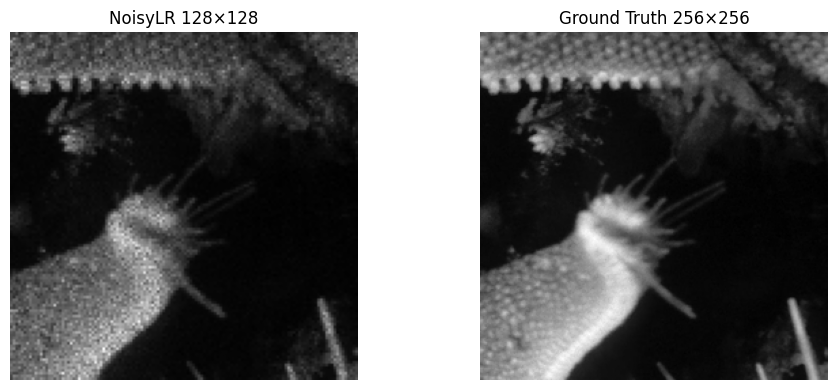

In [7]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title("NoisyLR 128×128")
plt.axis("off")


plt.subplot(1,2,2)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title("Ground Truth 256×256")
plt.axis("off")


plt.tight_layout()
plt.show()

In [8]:
class SemiconductorEDSRDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        file_list
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = file_list


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(
            np.float32
        )

        noisy = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(
            np.float32
        )

        gt_tensor = torch.from_numpy(
            gt
        ).unsqueeze(0)

        noisy_tensor = torch.from_numpy(
            noisy
        ).unsqueeze(0)

        return (
            noisy_tensor,
            gt_tensor
        )

In [9]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]

print("Total:", len(files))
print("Training:", len(train_files))
print("Validation:", len(val_files))
print("Testing:", len(test_files))

Total: 3200
Training: 2560
Validation: 320
Testing: 320


In [10]:
train_dataset = SemiconductorEDSRDataset(
    GT_PATH,
    NOISY_PATH,
    train_files
)

val_dataset = SemiconductorEDSRDataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = SemiconductorEDSRDataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test:",
    len(test_dataset)
)

Train: 2560
Validation: 320
Test: 320


In [11]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 320
Validation batches: 40
Test batches: 320


In [12]:
lr_batch, gt_batch = next(
    iter(train_loader)
)

print(
    "LR input:",
    lr_batch.shape
)

print(
    "GT target:",
    gt_batch.shape
)

LR input: torch.Size([8, 1, 128, 128])
GT target: torch.Size([8, 1, 256, 256])


In [13]:
class ResidualBlock(nn.Module):

    def __init__(
        self,
        channels=64,
        res_scale=0.1
    ):

        super(
            ResidualBlock,
            self
        ).__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.res_scale = res_scale


    def forward(
        self,
        x
    ):

        residual = self.conv1(
            x
        )

        residual = self.relu(
            residual
        )

        residual = self.conv2(
            residual
        )

        residual = (
            residual
            *
            self.res_scale
        )

        return x + residual

In [14]:
class EDSR(nn.Module):

    def __init__(
        self,
        channels=1,
        features=64,
        num_blocks=8,
        scale=2
    ):

        super(
            EDSR,
            self
        ).__init__()


        self.head = nn.Conv2d(
            channels,
            features,
            kernel_size=3,
            padding=1
        )


        body = []

        for _ in range(
            num_blocks
        ):

            body.append(
                ResidualBlock(
                    channels=features,
                    res_scale=0.1
                )
            )


        self.body = nn.Sequential(
            *body
        )


        self.body_conv = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )


        self.upconv = nn.Conv2d(
            features,
            features * scale * scale,
            kernel_size=3,
            padding=1
        )


        self.pixel_shuffle = nn.PixelShuffle(
            scale
        )


        self.tail = nn.Conv2d(
            features,
            channels,
            kernel_size=3,
            padding=1
        )


    def forward(
        self,
        x
    ):

        x = self.head(
            x
        )

        residual = x

        x = self.body(
            x
        )

        x = self.body_conv(
            x
        )

        x = x + residual

        x = self.upconv(
            x
        )

        x = self.pixel_shuffle(
            x
        )

        x = self.tail(
            x
        )

        return x

In [15]:
model = EDSR(
    channels=1,
    features=64,
    num_blocks=8,
    scale=2
).to(
    device
)

print(model)

EDSR(
  (head): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (2): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (3): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

In [16]:
test_input = torch.randn(
    1,
    1,
    128,
    128
).to(
    device
)

with torch.no_grad():

    test_output = model(
        test_input
    )

print(
    "Input shape:",
    test_input.shape
)

print(
    "Output shape:",
    test_output.shape
)

Input shape: torch.Size([1, 1, 128, 128])
Output shape: torch.Size([1, 1, 256, 256])


In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_params
)

print(
    "Trainable parameters:",
    trainable_params
)

Total parameters: 776705
Trainable parameters: 776705


In [18]:
criterion = nn.L1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print(
    "Loss: L1"
)

print(
    "Optimizer: Adam"
)

print(
    "Learning Rate: 0.0001"
)

Loss: L1
Optimizer: Adam
Learning Rate: 0.0001


In [19]:
MODEL_PATH = (
    "../models/edsr"
)

RESULT_PATH = (
    "../results/edsr"
)

RESTORED_PATH = (
    "../results/edsr/restored"
)

IMAGE_PATH = (
    "../results/edsr/images"
)

EXAMPLE_PATH = (
    "../results/edsr/examples"
)

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

os.makedirs(
    RESTORED_PATH,
    exist_ok=True
)

os.makedirs(
    IMAGE_PATH,
    exist_ok=True
)

os.makedirs(
    EXAMPLE_PATH,
    exist_ok=True
)

print(
    "EDSR folders created"
)

EDSR folders created


In [20]:
EPOCHS = 20

train_loss_history = []

val_loss_history = []

best_val_loss = float(
    "inf"
)


for epoch in range(
    EPOCHS
):


    # ======================
    # TRAINING
    # ======================

    model.train()

    running_train_loss = 0.0


    for (
        lr_img,
        gt_img
    ) in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):


        lr_img = lr_img.to(
            device
        )

        gt_img = gt_img.to(
            device
        )


        optimizer.zero_grad()


        output = model(
            lr_img
        )


        loss = criterion(
            output,
            gt_img
        )


        loss.backward()


        optimizer.step()


        running_train_loss += (
            loss.item()
        )


    train_loss = (
        running_train_loss
        /
        len(train_loader)
    )


    train_loss_history.append(
        train_loss
    )


    # ======================
    # VALIDATION
    # ======================

    model.eval()

    running_val_loss = 0.0


    with torch.no_grad():


        for (
            lr_img,
            gt_img
        ) in val_loader:


            lr_img = lr_img.to(
                device
            )

            gt_img = gt_img.to(
                device
            )


            output = model(
                lr_img
            )


            loss = criterion(
                output,
                gt_img
            )


            running_val_loss += (
                loss.item()
            )


    val_loss = (
        running_val_loss
        /
        len(val_loader)
    )


    val_loss_history.append(
        val_loss
    )


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    if val_loss < best_val_loss:


        best_val_loss = (
            val_loss
        )


        torch.save(
            model.state_dict(),
            "../models/edsr/edsr_best.pth"
        )


        print(
            "Best EDSR model saved."
        )

Epoch 1/20: 100%|██████████| 320/320 [00:20<00:00, 15.96it/s]


Epoch [01/20] Train Loss: 0.054174 | Val Loss: 0.042539
Best EDSR model saved.


Epoch 2/20: 100%|██████████| 320/320 [00:19<00:00, 16.33it/s]


Epoch [02/20] Train Loss: 0.038196 | Val Loss: 0.040514
Best EDSR model saved.


Epoch 3/20: 100%|██████████| 320/320 [00:19<00:00, 16.36it/s]


...

Epoch [18/20] Train Loss: 0.033818 | Val Loss: 0.034912


Epoch 19/20: 100%|██████████| 320/320 [00:19<00:00, 16.38it/s]


Epoch [19/20] Train Loss: 0.033371 | Val Loss: 0.034924


Epoch 20/20: 100%|██████████| 320/320 [00:19<00:00, 16.35it/s]


Epoch [20/20] Train Loss: 0.033296 | Val Loss: 0.034727
Best EDSR model saved.


In [21]:
torch.save(
    model.state_dict(),
    "../models/edsr/edsr_final.pth"
)

print(
    "Final EDSR model saved"
)

Final EDSR model saved


In [22]:
history_df = pd.DataFrame({

    "Epoch":
        range(
            1,
            EPOCHS + 1
        ),

    "Train_Loss":
        train_loss_history,

    "Validation_Loss":
        val_loss_history

})

history_df.to_csv(
    "../results/edsr/training_history.csv",
    index=False
)

history_df

,Epoch,Train_Loss,Validation_Loss
0,1,0.054174,0.042539
1,2,0.038196,0.040514
2,3,0.036259,0.037348
3,4,0.035744,0.037201
4,5,0.034921,0.036454
5,6,0.035057,0.036187
6,7,0.034880,0.037369
7,8,0.034705,0.037052
8,9,0.034527,0.035681
9,10,0.034267,0.041772


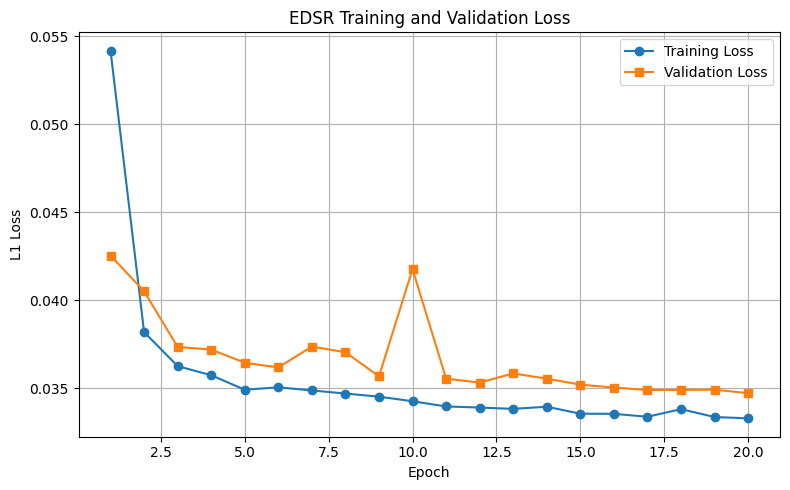

In [23]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    range(
        1,
        EPOCHS + 1
    ),
    train_loss_history,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(
        1,
        EPOCHS + 1
    ),
    val_loss_history,
    marker="s",
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "L1 Loss"
)

plt.title(
    "EDSR Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/edsr/training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
best_model = EDSR(
    channels=1,
    features=64,
    num_blocks=8,
    scale=2
).to(
    device
)

best_model.load_state_dict(
    torch.load(
        "../models/edsr/edsr_best.pth",
        map_location=device
    )
)

best_model.eval()

print(
    "Best EDSR model loaded"
)

Best EDSR model loaded


/tmp/ipykernel_1988943/1343899545.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [25]:
psnr_scores = []

ssim_scores = []

mse_scores = []

inference_times = []


best_model.eval()


with torch.no_grad():


    for i, (
        lr_img,
        gt_img
    ) in enumerate(
        tqdm(
            test_loader,
            desc="Testing EDSR"
        )
    ):


        lr_img = lr_img.to(
            device
        )


        if device.type == "cuda":
            torch.cuda.synchronize()


        start_time = (
            time.perf_counter()
        )


        output = best_model(
            lr_img
        )


        if device.type == "cuda":
            torch.cuda.synchronize()


        end_time = (
            time.perf_counter()
        )


        inference_ms = (
            end_time - start_time
        ) * 1000


        output = torch.clamp(
            output,
            0,
            1
        )


        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
        )


        gt = (
            gt_img
            .squeeze()
            .numpy()
        )


        current_psnr = (
            peak_signal_noise_ratio(
                gt,
                restored,
                data_range=1.0
            )
        )


        current_ssim = (
            structural_similarity(
                gt,
                restored,
                data_range=1.0
            )
        )


        current_mse = (
            mean_squared_error(
                gt,
                restored
            )
        )


        psnr_scores.append(
            current_psnr
        )


        ssim_scores.append(
            current_ssim
        )


        mse_scores.append(
            current_mse
        )


        inference_times.append(
            inference_ms
        )


        filename = (
            test_files[i]
        )


        np.save(
            os.path.join(
                RESTORED_PATH,
                filename
            ),
            restored
        )


print(
    "EDSR testing completed"
)

Testing EDSR: 100%|██████████| 320/320 [00:02<00:00, 111.00it/s]

EDSR testing completed


In [26]:
avg_psnr = np.mean(
    psnr_scores
)

avg_ssim = np.mean(
    ssim_scores
)

avg_mse = np.mean(
    mse_scores
)

avg_inference = np.mean(
    inference_times
)


print(
    "========== EDSR FINAL RESULTS =========="
)

print(
    f"Average PSNR: {avg_psnr:.6f} dB"
)

print(
    f"Average SSIM: {avg_ssim:.6f}"
)

print(
    f"Average MSE: {avg_mse:.8f}"
)

print(
    f"Average Inference Time: "
    f"{avg_inference:.3f} ms/image"
)

========== EDSR FINAL RESULTS ==========
Average PSNR: 27.986647 dB
Average SSIM: 0.742506
Average MSE: 0.00260034
Average Inference Time: 2.672 ms/image


In [27]:
metrics_df = pd.DataFrame({

    "Filename":
        test_files,

    "PSNR_dB":
        psnr_scores,

    "SSIM":
        ssim_scores,

    "MSE":
        mse_scores,

    "Inference_Time_ms":
        inference_times

})

metrics_df.to_csv(
    "../results/edsr/per_image_metrics.csv",
    index=False
)

metrics_df.head(
    10
)

,Filename,PSNR_dB,SSIM,MSE,Inference_Time_ms
0,001218.npy,27.297891,0.775224,0.001863,4.329226
1,001158.npy,28.014330,0.523558,0.001580,2.827978
2,001415.npy,21.213012,0.712589,0.007563,2.685593
3,002896.npy,28.922331,0.804873,0.001282,2.720106
4,001527.npy,35.818696,0.911034,0.000262,2.685210
5,003113.npy,24.914825,0.803674,0.003225,2.691569
6,001300.npy,33.583940,0.888936,0.000438,2.672110
7,003056.npy,23.658579,0.681371,0.004307,2.673675
8,002848.npy,30.447090,0.726883,0.000902,2.694086
9,001603.npy,26.061521,0.763093,0.002477,2.867909


In [28]:
with open(
    "../results/edsr/metrics.txt",
    "w"
) as f:


    f.write(
        "Experiment: EDSR Baseline\n"
    )

    f.write(
        "==========================\n\n"
    )

    f.write(
        "Dataset: KLA Semiconductor Image Restoration\n\n"
    )

    f.write(
        f"Training Samples: {len(train_files)}\n"
    )

    f.write(
        f"Validation Samples: {len(val_files)}\n"
    )

    f.write(
        f"Testing Samples: {len(test_files)}\n\n"
    )

    f.write(
        "Input: NoisyLR 128x128\n"
    )

    f.write(
        "Upsampling: Learned PixelShuffle x2\n"
    )

    f.write(
        "Output: 256x256\n"
    )

    f.write(
        "Residual Blocks: 8\n\n"
    )

    f.write(
        f"Average PSNR: {avg_psnr:.6f} dB\n"
    )

    f.write(
        f"Average SSIM: {avg_ssim:.6f}\n"
    )

    f.write(
        f"Average MSE: {avg_mse:.10f}\n"
    )

    f.write(
        f"Average Inference Time: "
        f"{avg_inference:.4f} ms/image\n"
    )

    f.write(
        f"Model Parameters: {total_params}\n"
    )


print(
    "EDSR metrics saved"
)

EDSR metrics saved


In [29]:
bicubic_psnr = []

bicubic_ssim = []

bicubic_mse = []


for filename in tqdm(
    test_files,
    desc="Bicubic evaluation"
):


    gt = np.load(
        os.path.join(
            GT_PATH,
            filename
        )
    ).astype(
        np.float32
    )


    noisy = np.load(
        os.path.join(
            NOISY_PATH,
            filename
        )
    ).astype(
        np.float32
    )


    bicubic = resize(
        noisy,
        gt.shape,
        order=3,
        anti_aliasing=True,
        preserve_range=True
    )


    bicubic_psnr.append(
        peak_signal_noise_ratio(
            gt,
            bicubic,
            data_range=1.0
        )
    )


    bicubic_ssim.append(
        structural_similarity(
            gt,
            bicubic,
            data_range=1.0
        )
    )


    bicubic_mse.append(
        mean_squared_error(
            gt,
            bicubic
        )
    )


print(
    "Bicubic PSNR:",
    np.mean(
        bicubic_psnr
    )
)

print(
    "Bicubic SSIM:",
    np.mean(
        bicubic_ssim
    )
)

print(
    "Bicubic MSE:",
    np.mean(
        bicubic_mse
    )
)

Bicubic evaluation: 100%|██████████| 320/320 [00:03<00:00, 97.84it/s]

Bicubic PSNR: 22.478415628140233
Bicubic SSIM: 0.5116624465067319
Bicubic MSE: 0.007338321273890881


In [30]:
srcnn_psnr = 27.52943205674495
srcnn_ssim = 0.7250710888767316
srcnn_mse = 0.0027344456903774946


dncnn_psnr = 27.893001035080903
dncnn_ssim = 0.7249596254696442
dncnn_mse = 0.0025748269964531107


print(
    "SRCNN:",
    srcnn_psnr,
    srcnn_ssim,
    srcnn_mse
)

print(
    "DnCNN:",
    dncnn_psnr,
    dncnn_ssim,
    dncnn_mse
)

SRCNN: 27.52943205674495 0.7250710888767316 0.0027344456903774946
DnCNN: 27.893001035080903 0.7249596254696442 0.0025748269964531107


In [31]:
comparison_df = pd.DataFrame({

    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR"
    ],


    "PSNR_dB": [

        np.mean(
            bicubic_psnr
        ),

        srcnn_psnr,

        dncnn_psnr,

        avg_psnr
    ],


    "SSIM": [

        np.mean(
            bicubic_ssim
        ),

        srcnn_ssim,

        dncnn_ssim,

        avg_ssim
    ],


    "MSE": [

        np.mean(
            bicubic_mse
        ),

        srcnn_mse,

        dncnn_mse,

        avg_mse
    ]

})


comparison_df.to_csv(
    "../results/edsr/baseline_comparison.csv",
    index=False
)


comparison_df

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575
3,EDSR,27.986647,0.742506,0.002600


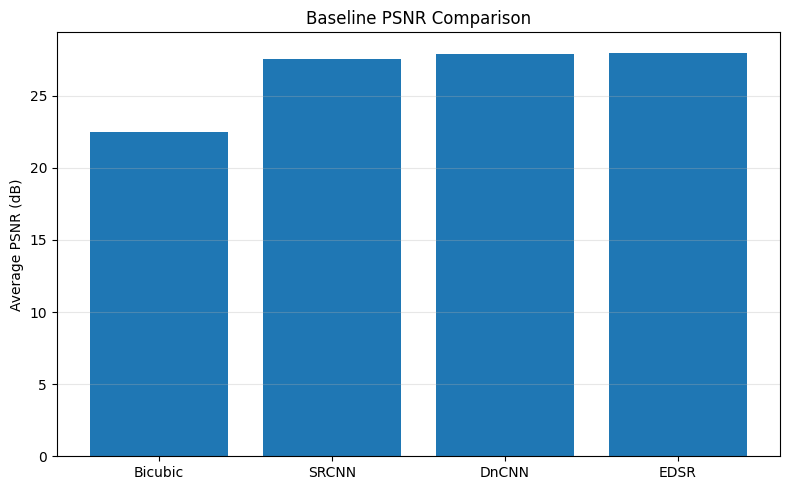

In [32]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["PSNR_dB"]
)

plt.ylabel(
    "Average PSNR (dB)"
)

plt.title(
    "Baseline PSNR Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/edsr/psnr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

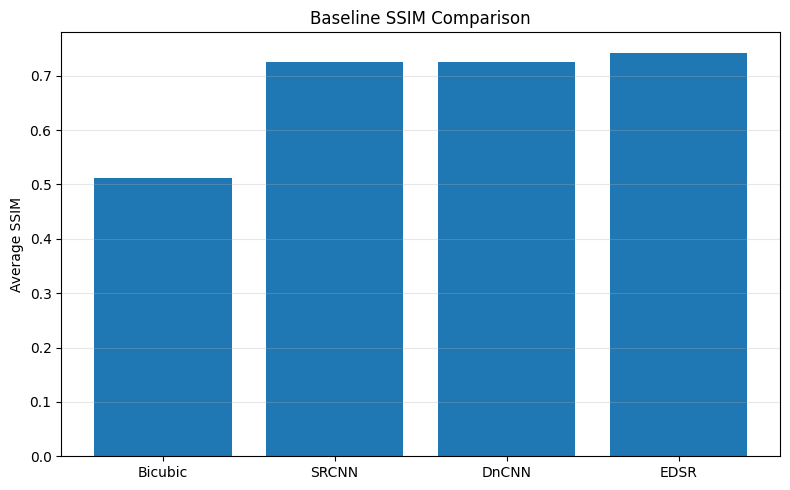

In [33]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["SSIM"]
)

plt.ylabel(
    "Average SSIM"
)

plt.title(
    "Baseline SSIM Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/edsr/ssim_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

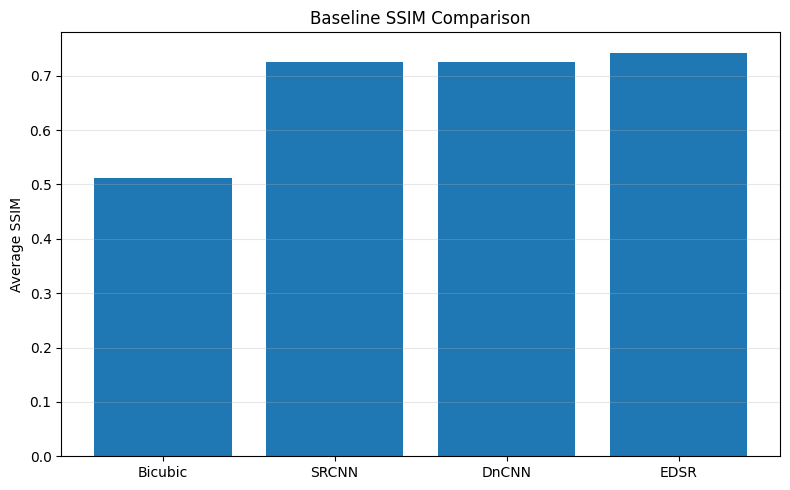

In [34]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["SSIM"]
)

plt.ylabel(
    "Average SSIM"
)

plt.title(
    "Baseline SSIM Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/edsr/ssim_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

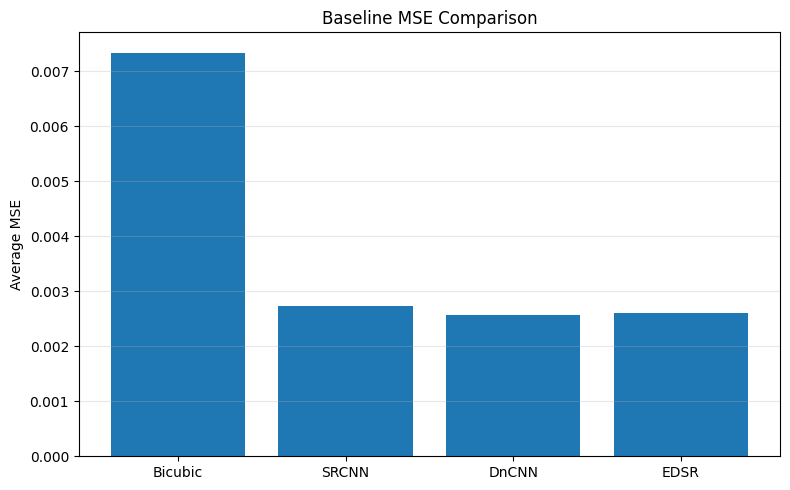

In [35]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison_df["Method"],
    comparison_df["MSE"]
)

plt.ylabel(
    "Average MSE"
)

plt.title(
    "Baseline MSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../results/edsr/mse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
restored_files = sorted([
    f for f in os.listdir(
        RESTORED_PATH
    )
    if f.endswith(
        ".npy"
    )
])


print(
    "EDSR restored files:",
    len(restored_files)
)


for filename in tqdm(
    restored_files
):


    image = np.load(
        os.path.join(
            RESTORED_PATH,
            filename
        )
    )


    png_name = filename.replace(
        ".npy",
        ".png"
    )


    plt.imsave(
        os.path.join(
            IMAGE_PATH,
            png_name
        ),
        image,
        cmap="gray"
    )


print(
    "EDSR PNG images saved"
)

EDSR restored files: 320


100%|██████████| 320/320 [00:06<00:00, 48.23it/s]

EDSR PNG images saved


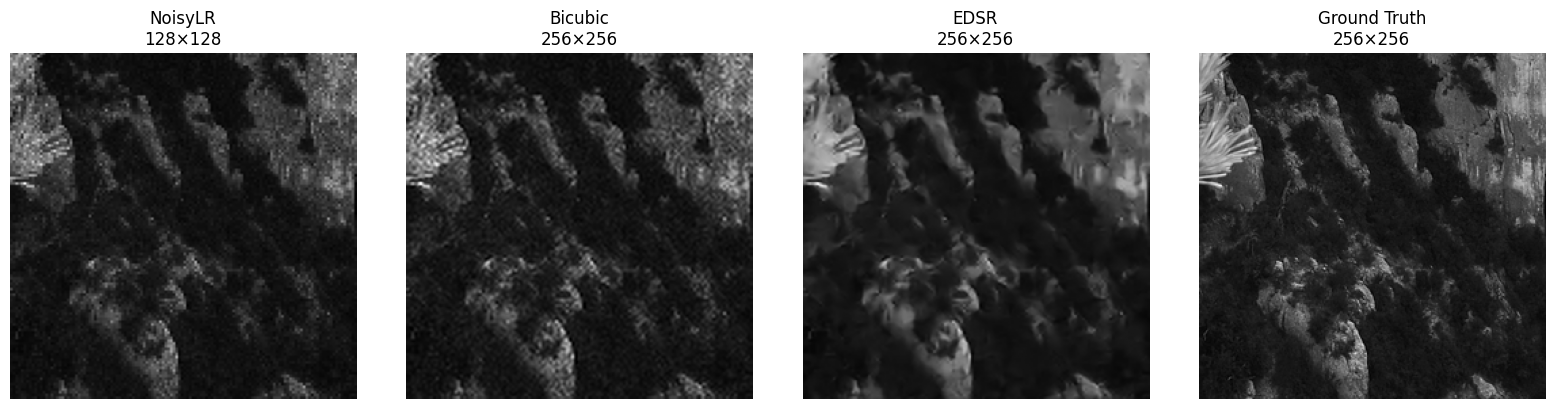

In [37]:
sample_file = test_files[0]


gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
)


noisy = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
)


bicubic = resize(
    noisy,
    gt.shape,
    order=3,
    anti_aliasing=True,
    preserve_range=True
)


edsr = np.load(
    os.path.join(
        RESTORED_PATH,
        sample_file
    )
)


plt.figure(
    figsize=(16,4)
)


plt.subplot(1,4,1)

plt.imshow(
    noisy,
    cmap="gray"
)

plt.title(
    "NoisyLR\n128×128"
)

plt.axis("off")


plt.subplot(1,4,2)

plt.imshow(
    bicubic,
    cmap="gray"
)

plt.title(
    "Bicubic\n256×256"
)

plt.axis("off")


plt.subplot(1,4,3)

plt.imshow(
    edsr,
    cmap="gray"
)

plt.title(
    "EDSR\n256×256"
)

plt.axis("off")


plt.subplot(1,4,4)

plt.imshow(
    gt,
    cmap="gray"
)

plt.title(
    "Ground Truth\n256×256"
)

plt.axis("off")


plt.tight_layout()

plt.savefig(
    "../results/edsr/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

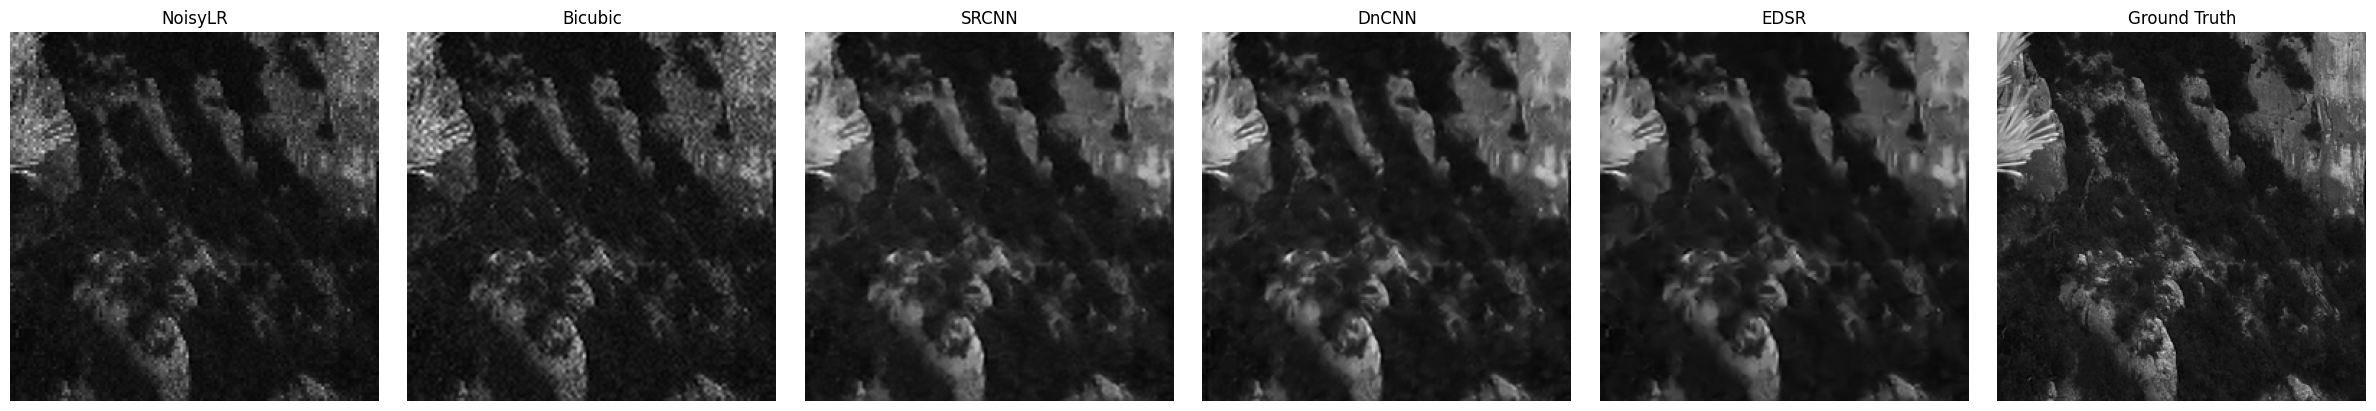

In [38]:
SRCNN_PATH = (
    "../results/srcnn/restored"
)

DNCNN_PATH = (
    "../results/dncnn/restored"
)


srcnn_file = os.path.join(
    SRCNN_PATH,
    sample_file
)

dncnn_file = os.path.join(
    DNCNN_PATH,
    sample_file
)


if (
    os.path.exists(srcnn_file)
    and
    os.path.exists(dncnn_file)
):


    srcnn = np.load(
        srcnn_file
    )


    dncnn = np.load(
        dncnn_file
    )


    plt.figure(
        figsize=(24,4)
    )


    images = [
        noisy,
        bicubic,
        srcnn,
        dncnn,
        edsr,
        gt
    ]


    titles = [
        "NoisyLR",
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR",
        "Ground Truth"
    ]


    for i in range(
        6
    ):


        plt.subplot(
            1,
            6,
            i+1
        )


        plt.imshow(
            images[i],
            cmap="gray"
        )


        plt.title(
            titles[i]
        )


        plt.axis(
            "off"
        )


    plt.tight_layout()


    plt.savefig(
        "../results/edsr/all_baselines_visual.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


else:

    print(
        "SRCNN or DnCNN output for this test image not found."
    )

In [39]:
import shutil


sample_files = (
    test_files[:5]
)


for filename in sample_files:


    png_name = filename.replace(
        ".npy",
        ".png"
    )


    src = os.path.join(
        IMAGE_PATH,
        png_name
    )


    dst = os.path.join(
        EXAMPLE_PATH,
        png_name
    )


    if os.path.exists(
        src
    ):

        shutil.copy(
            src,
            dst
        )


print(
    "Example EDSR images copied"
)

Example EDSR images copied


In [40]:
bicubic_avg_psnr = np.mean(
    bicubic_psnr
)

bicubic_avg_ssim = np.mean(
    bicubic_ssim
)

bicubic_avg_mse = np.mean(
    bicubic_mse
)


print(
    "========== EDSR IMPROVEMENT =========="
)


print(
    f"PSNR gain over Bicubic: "
    f"{avg_psnr - bicubic_avg_psnr:.4f} dB"
)


print(
    f"PSNR gain over SRCNN: "
    f"{avg_psnr - srcnn_psnr:.4f} dB"
)


print(
    f"PSNR gain over DnCNN: "
    f"{avg_psnr - dncnn_psnr:.4f} dB"
)


print()


print(
    f"SSIM gain over Bicubic: "
    f"{avg_ssim - bicubic_avg_ssim:.4f}"
)


print(
    f"SSIM gain over SRCNN: "
    f"{avg_ssim - srcnn_ssim:.4f}"
)


print(
    f"SSIM gain over DnCNN: "
    f"{avg_ssim - dncnn_ssim:.4f}"
)


print()


mse_reduction_dncnn = (
    (
        dncnn_mse
        -
        avg_mse
    )
    /
    dncnn_mse
) * 100


print(
    f"MSE reduction over DnCNN: "
    f"{mse_reduction_dncnn:.2f}%"
)

========== EDSR IMPROVEMENT ==========
PSNR gain over Bicubic: 5.5082 dB
PSNR gain over SRCNN: 0.4572 dB
PSNR gain over DnCNN: 0.0936 dB

SSIM gain over Bicubic: 0.2308
SSIM gain over SRCNN: 0.0174
SSIM gain over DnCNN: 0.0175

MSE reduction over DnCNN: -0.99%


In [41]:
complexity_df = pd.DataFrame({

    "Model": [
        "EDSR"
    ],

    "Parameters": [
        total_params
    ],

    "Residual_Blocks": [
        8
    ],

    "Scale": [
        2
    ],

    "Average_Inference_ms": [
        avg_inference
    ]

})


complexity_df.to_csv(
    "../results/edsr/model_complexity.csv",
    index=False
)


complexity_df

,Model,Parameters,Residual_Blocks,Scale,Average_Inference_ms
0,EDSR,776705,8,2,2.67198


In [42]:
print(
    "========== EDSR OUTPUT CHECK =========="
)


print(
    "Best model:",
    os.path.exists(
        "../models/edsr/edsr_best.pth"
    )
)


print(
    "Final model:",
    os.path.exists(
        "../models/edsr/edsr_final.pth"
    )
)


print(
    "Metrics:",
    os.path.exists(
        "../results/edsr/metrics.txt"
    )
)


print(
    "Training history:",
    os.path.exists(
        "../results/edsr/training_history.csv"
    )
)


print(
    "Baseline comparison:",
    os.path.exists(
        "../results/edsr/baseline_comparison.csv"
    )
)


print(
    "Visual comparison:",
    os.path.exists(
        "../results/edsr/comparison.png"
    )
)


print(
    "Restored NPY files:",
    len([
        f for f in os.listdir(
            RESTORED_PATH
        )
        if f.endswith(
            ".npy"
        )
    ])
)


print(
    "PNG files:",
    len([
        f for f in os.listdir(
            IMAGE_PATH
        )
        if f.endswith(
            ".png"
        )
    ])
)

========== EDSR OUTPUT CHECK ==========
Best model: True
Final model: True
Metrics: True
Training history: True
Baseline comparison: True
Visual comparison: True
Restored NPY files: 320
PNG files: 320
